Dataset Columns:
Index(['id', 'full_name', 'age', 'gender', 'smoking_status', 'bmi',
       'blood_pressure', 'glucose_levels', 'condition'],
      dtype='object')

First 5 Rows:
      id full_name   age gender smoking_status        bmi  blood_pressure  \
22    23  User0023  49.0   male     Non-Smoker  28.025453      119.212083   
63    64  User0064  43.0   male     Non-Smoker  34.978378      107.052200   
84    85  User0085  52.0   male         Smoker  25.024378      131.071030   
89    90  User0090  70.0   male         Smoker  39.249085      113.848795   
153  154  User0154  66.0   male         Smoker  24.333718      173.787158   

     glucose_levels  condition  
22       150.628025  Pneumonia  
63       190.482674   Diabetic  
84       185.997004   Diabetic  
89       124.264664  Pneumonia  
153      130.727447   Diabetic  

Disease Distribution:
condition
Diabetic     265
Pneumonia    115
Cancer        66
Name: count, dtype: int64


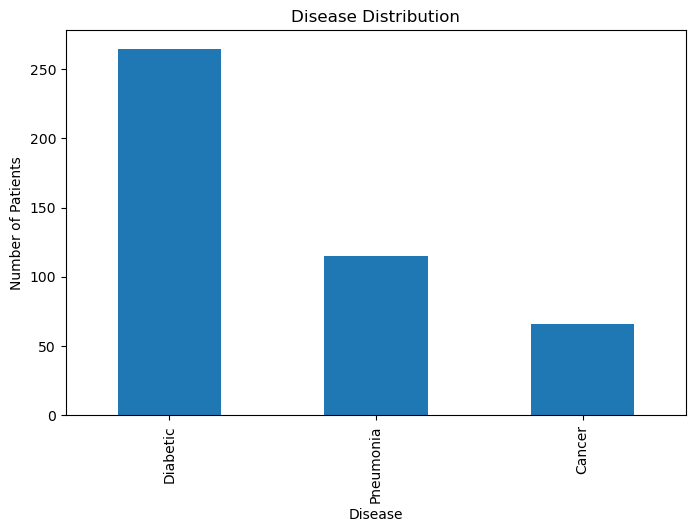


Column 'smoking' not found

Required columns for scatter plot not found

Columns for Risk Prediction not found

Project Completed Successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("medical_data.csv")

# Clean Column Names
df.columns = df.columns.str.strip().str.lower()

# Show Column Names
print("Dataset Columns:")
print(df.columns)

# Remove Missing Values
df = df.dropna()

# Show First 5 Rows
print("\nFirst 5 Rows:")
print(df.head())

# Disease Distribution Chart
if 'condition' in df.columns:

    print("\nDisease Distribution:")
    print(df['condition'].value_counts())

    plt.figure(figsize=(8,5))

    df['condition'].value_counts().plot(
        kind='bar'
    )

    plt.title("Disease Distribution")
    plt.xlabel("Disease")
    plt.ylabel("Number of Patients")

    plt.show()

else:
    print("\nColumn 'condition' not found")

# Smoking Habit Pie Chart
if 'smoking' in df.columns:

    plt.figure(figsize=(6,6))

    df['smoking'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.title("Smoking Habits")
    plt.ylabel("")

    plt.show()

else:
    print("\nColumn 'smoking' not found")

# BMI vs Glucose Scatter Plot
if 'glucose_level' in df.columns and 'bmi' in df.columns:

    plt.figure(figsize=(7,5))

    plt.scatter(
        df['glucose_level'],
        df['bmi']
    )

    plt.title("BMI vs Glucose Level")
    plt.xlabel("Glucose Level")
    plt.ylabel("BMI")

    plt.show()

else:
    print("\nRequired columns for scatter plot not found")

# Risk Prediction Function
def risk(glucose, bp):

    if glucose > 140 and bp > 140:
        return "High Risk"

    elif glucose > 120:
        return "Medium Risk"

    else:
        return "Low Risk"

# Create Risk Level Column
if 'glucose_level' in df.columns and 'blood_pressure' in df.columns:

    df['risk_level'] = df.apply(
        lambda x: risk(
            x['glucose_level'],
            x['blood_pressure']
        ),
        axis=1
    )

    # Display Risk Levels
    if 'full_name' in df.columns:

        print("\nPatient Risk Levels:")
        print(df[['full_name', 'risk_level']].head())

    else:
        print("\nRisk Level Created Successfully")

else:
    print("\nColumns for Risk Prediction not found")

# Save Processed Dataset
df.to_csv(
    "processed_medical_data.csv",
    index=False
)

print("\nProject Completed Successfully")